In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/aleksei/projects/code-of-kutulu-client')

In [3]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime
import pickle as pkl
import zlib
import base64

In [4]:
TEST_STATES = [
    ((4,), 0, None, None),
    ((0,), 1, None, None),
    ((1,), 1, None, None),
    ((2,), 1, None, None),
    ((3,), 1, None, None),
    ((0,), 2, None, None),
    ((1,), 2, None, None),
    ((2,), 2, None, None),
    ((3,), 2, None, None),
    ((0,), 3, None, None),
    ((1,), 3, None, None),
    ((2,), 3, None, None),
    ((3,), 3, None, None),
    ((0,), 4, None, None),
    ((1,), 4, None, None),
    ((2,), 4, None, None),
    ((3,), 4, None, None),
]

In [5]:
def check_policy(Q):
    result_list = []
    for state in TEST_STATES:
        _dir = state[0][0]
        result = np.argmax(Q.get(state, [0])) == _dir
        result_list.append(result)
    return np.mean(result_list)

In [6]:
def load_strategy(checkpoint_dir):
    with open(f"{checkpoint_dir}/data1.pkl", "rb") as f:
        vals = pkl.loads(f.read())
    with open(f"{checkpoint_dir}/data2.pkl", "rb") as f:
        keys = pkl.loads(f.read())

    new_pi = LazyGreedyStrategy()
    new_pi.Q = dict(zip(keys, vals))
    return new_pi

In [7]:
from src.envs.kutulu_world import KutuluWorldEnv, DEFAULT_KUTULU_ACTIONS
from src.envs.distance import find_path
from src.envs.kutulu_player import KutuluPlayer
from src.envs.strategy import RandomStrategy, GreedyStrategy, LazyGreedyStrategy

In [8]:
training_pi = LazyGreedyStrategy()
eps=0.05
alpha=0.3
gamma=0.5
num_experiments=2000
can_wait=True
verbose=False
reward_list = []
quality_list = []
players_map_list = []

In [9]:
Q = training_pi.Q

In [10]:
maze_names = [
    "PacMan",
    "Hypersonic",
    "Oasis",
    "Corridors",
    "OriginOfSymmetry",
    "FourOfAKind"
]

In [11]:
game_players = [
    training_pi,
    load_strategy('../output/2025-05-01/02:19:04.597189'),
    RandomStrategy(),
    RandomStrategy(),
]
players_map = np.arange(len(game_players))

In [12]:
for i in tqdm(range(num_experiments)):
    maze_name = np.random.choice(maze_names)
#     maze_name = 'OriginOfSymmetry'
    env = KutuluWorldEnv(
        server_host='localhost:8080',
        maze_name=maze_name,
        league_level=1,
        players_count=4,
    )
    player = KutuluPlayer(env)
    observation, info = env.reset()
    np.random.shuffle(players_map)
    rollout_rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
        
        state_actions = {}
        for env_player in env.active_players():
            player_id = env_player['id']
            game_player_id = players_map[player_id]
            if game_players[game_player_id] is None:
                continue
            _pi = game_players[game_player_id]
            state = player.get_state(player_id)
            player_mask = ~np.array(player.env.get_valid_action_mask()[player_id])
            At = _pi.getActionEpsGreedyMasked(state, len(DEFAULT_KUTULU_ACTIONS), eps, player_mask)
            action[player_id] = At
            state_actions[player_id] = (state, At)

        entities, rewards, game_over, info = env.step(action)
        rollout_rewards.append(rewards)

        for player_id, reward in enumerate(rewards):
            game_player_id = players_map[player_id]
            if game_players[game_player_id] is not training_pi:
                continue
            if reward is None:
                continue
            if player_id not in state_actions:
                continue
            state, At = state_actions[player_id]
            
            if game_over:
                Q[state][At] += alpha * (reward - Q[state][At])
            else:
                Q[state][At] += alpha * (
                    reward + gamma * Q[state].max() - Q[state][At]
                )
        
        if verbose:
            viz_map(env.map, entities['entities'])

#     reward_list.append(rollout_rewards)
    rollout_rewards = np.array(rollout_rewards, dtype=float)[:,np.argsort(players_map)]
    reward_list.append(rollout_rewards)
    quality_list.append(check_policy(training_pi.Q))
    players_map_list.append(players_map)
    if i % 10 == 0:
        total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])
        mean_rewards = np.mean(total_reward_list, axis=0)
        print(f"i={i}\tquality={quality_list[-1]:.2f}\tmean_reward=[{', '.join(f'{x:.2f}' for x in mean_rewards)}]")

  0%|          | 1/2000 [00:00<21:02,  1.58it/s]

i=0	quality=0.12	mean_reward=[854.00, -156.00, -188.00, -166.00]


  1%|          | 11/2000 [00:06<20:35,  1.61it/s]

i=10	quality=0.24	mean_reward=[201.09, 234.18, 0.18, -74.18]


  1%|          | 21/2000 [00:13<21:44,  1.52it/s]

...

 99%|█████████▉| 1981/2000 [28:09<00:11,  1.61it/s]

i=1980	quality=0.76	mean_reward=[196.30, 172.10, 14.97, 8.13]


100%|█████████▉| 1991/2000 [28:15<00:06,  1.41it/s]

i=1990	quality=0.71	mean_reward=[196.67, 172.04, 14.49, 8.26]


100%|██████████| 2000/2000 [28:21<00:00,  1.18it/s]


In [13]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [14]:
winner_list = np.argmax(total_reward_list, 1)

In [15]:
Counter(winner_list)

Counter({0: 656, 1: 612, 2: 373, 3: 359})

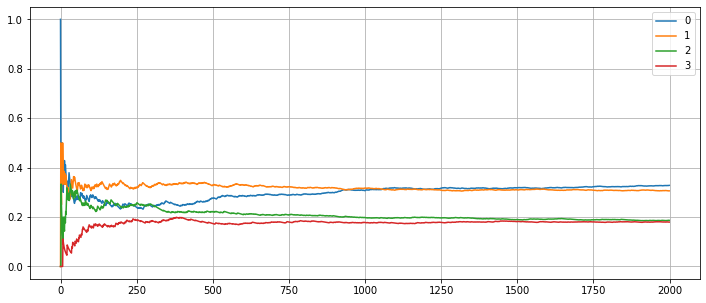

In [16]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

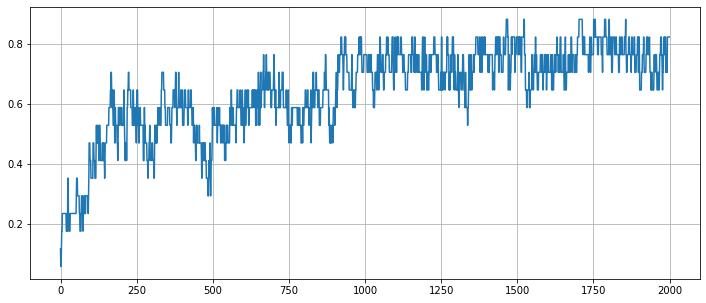

In [17]:
plt.figure(figsize=(12, 5))
sns.lineplot(quality_list)
_ = plt.grid()

In [18]:
num_experiments=100
can_wait=True
verbose=False
reward_list = []

In [19]:
maze_names = [
    "PacMan",
    "Hypersonic",
    "Oasis",
    "Corridors",
    "OriginOfSymmetry",
    "FourOfAKind"
]

In [20]:
game_players = [
    training_pi,
    load_strategy('../output/2025-05-01/02:19:04.597189'),
    load_strategy('../output/2025-05-01/02:19:04.597189'),
    load_strategy('../output/2025-05-01/02:19:04.597189'),
]
players_map = np.arange(len(game_players))

In [21]:
for i in tqdm(range(num_experiments)):
    maze_name = np.random.choice(maze_names)
#     maze_name = 'OriginOfSymmetry'
    env = KutuluWorldEnv(
        server_host='localhost:8080',
        maze_name=maze_name,
        league_level=1,
        players_count=4,
    )
    player = KutuluPlayer(env)
    observation, info = env.reset()
    np.random.shuffle(players_map)
    rollout_rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
        
        state_actions = {}
        for env_player in env.active_players():
            player_id = env_player['id']
            game_player_id = players_map[player_id]
            if game_players[game_player_id] is None:
                continue
            _pi = game_players[game_player_id]
            state = player.get_state(player_id)
            player_mask = ~np.array(player.env.get_valid_action_mask()[player_id])
            At = _pi.getActionEpsGreedyMasked(state, len(DEFAULT_KUTULU_ACTIONS), eps, player_mask)
            action[player_id] = At
            state_actions[player_id] = (state, At)

        entities, rewards, game_over, info = env.step(action)
        rollout_rewards.append(rewards)
    rollout_rewards = np.array(rollout_rewards, dtype=float)[:,np.argsort(players_map)]
    reward_list.append(rollout_rewards)

100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


In [22]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [23]:
winner_list = np.argmax(total_reward_list, 1)

In [24]:
Counter(winner_list)

Counter({0: 26, 2: 22, 3: 22, 1: 30})

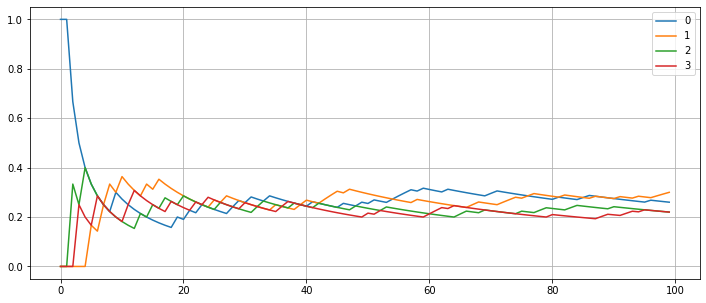

In [25]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [26]:
check_policy(Q)

0.8235294117647058

In [28]:
len([k for k in training_pi.Q.keys()])

2222

In [29]:
# new_keys = [k for k in pi.Q.keys() if ((k[1] or 0) < 8) and ((k[3] or 0) < 6)]
new_keys = list(training_pi.Q.keys())

In [30]:
len(new_keys)

2222

In [31]:
data1 = pkl.dumps(np.array(list(training_pi.Q[k] for k in new_keys), dtype='float16'))
data2 = pkl.dumps(list(new_keys))

In [32]:
len(base64.b64encode(zlib.compress(data1, level=9)))

27848

In [33]:
len(base64.b64encode(zlib.compress(data2, level=9)))

27568

In [34]:
model_dir = f"../output/{datetime.now()}"
date, time = model_dir.split()
try:
    os.mkdir(date, )
except:
    pass
os.mkdir(f"{date}/{time}")
with open(f"{date}/{time}/data1.pkl", "wb") as f:
    f.write(data1)
with open(f"{date}/{time}/data2.pkl", "wb") as f:
    f.write(data2)

In [35]:
print(f"{date}/{time}")

../output/2025-05-01/03:12:02.284385


In [36]:
# base64.b64encode(zlib.compress(data2, level=9))

In [37]:
with open('../src/game/template.py') as f:
    lines = f.readlines()

In [38]:
with open('../src/game/template_submit.py', 'w') as f:
    for line in lines:
        line = line.replace("b'data1data1data1'", str(base64.b64encode(zlib.compress(data1, level=9))))
        line = line.replace("b'data2data2data2'", str(base64.b64encode(zlib.compress(data2, level=9))))
        f.write(line)

In [39]:
!ls -lh ../src/game/template_submit.py

-rw-r--r--  1 aleksei  staff    61K  1 май 03:12 ../src/game/template_submit.py
